# This notebook includes experimentaion and implementation of function transformers like:
<li> log transformer
<li> Reciprocal transformer
<li> square transformer
<li> sq. root transformer

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import scipy.stats as stats


In [127]:
df = sns.load_dataset("titanic")
df = df[['age','fare','survived']]
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [128]:
df.isnull().sum()

age         177
fare          0
survived      0
dtype: int64

In [129]:
df['age'] = df['age'].fillna(df['age'].mean())

In [130]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df.iloc[:,-1],test_size=0.3,random_state=12)

In [143]:
y_test

456    0
351    0
173    0
671    0
836    0
      ..
860    0
69     0
647    1
872    0
669    1
Name: survived, Length: 268, dtype: int64

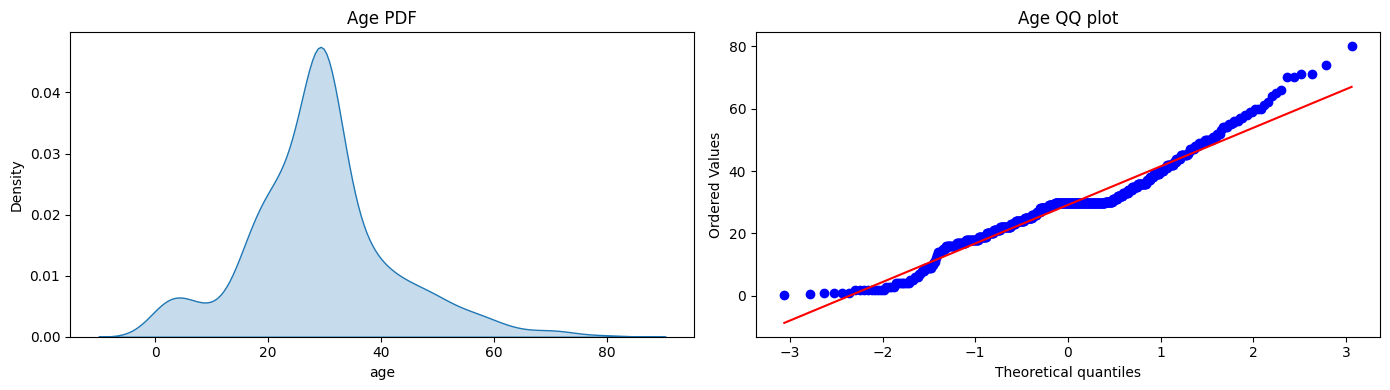

In [138]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,4))

ax1.set_title("Age PDF")
sns.kdeplot(X_train['age'],fill=True,ax= ax1)


stats.probplot(X_train['age'],dist="norm",plot=ax2) # probplot internally calls ax.title(...), which overwrites your title if you set it before the call. 
plt.tight_layout()
ax2.set_title("Age QQ plot")

plt.show()

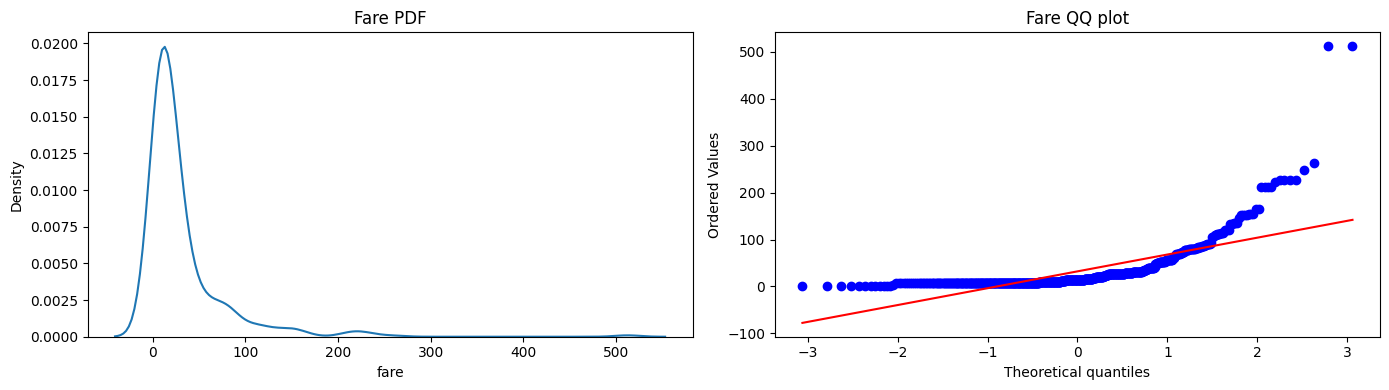

In [137]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,4))

ax1.set_title("Fare PDF")
sns.kdeplot(X_train['fare'],ax=ax1) 

stats.probplot(X_train['fare'],dist='norm',plot=ax2)
plt.tight_layout()
ax2.set_title("Fare QQ plot")

plt.show()

In [140]:
from scipy.stats import logistic
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier()
clf2 = LogisticRegression()


In [147]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("DT accuracy: ", accuracy_score(y_test,y_pred))
print("LR accuracy: ",accuracy_score(y_test,y_pred))


DT accuracy:  0.6529850746268657
LR accuracy:  0.6529850746268657


/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
